In [1]:
import os, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

PROJECT_ROOT = Path(r"C:\Users\Admin\lungprints")
DATA_DIR     = Path(r"C:\Users\Admin\lungprints\data\pneumonia\chest_xray")
FIG_DIR      = PROJECT_ROOT / "results" / "figures"
RES_DIR      = PROJECT_ROOT / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("DATA_DIR:", DATA_DIR)
print("Exists:", DATA_DIR.exists())

DATA_DIR: C:\Users\Admin\lungprints\data\pneumonia\chest_xray
Exists: True


In [ ]:
# gather file paths and labels
class_to_idx = {"NORMAL": 0, "PNEUMONIA": 1}

# Merge train + val into one pool (val has only 16 images)
pool_files, pool_labels = [], []
for split in ["train", "val"]:
    for cls, idx in class_to_idx.items():
        for f in (DATA_DIR / split / cls).glob("*"):
            if f.suffix.lower() in [".jpeg", ".jpg", ".png"]:
                pool_files.append(f)
                pool_labels.append(idx)

# Test set (untouched from here on)
test_files, test_labels = [], []
for cls, idx in class_to_idx.items():
    for f in (DATA_DIR / "test" / cls).glob("*"):
        if f.suffix.lower() in [".jpeg", ".jpg", ".png"]:
            test_files.append(f)
            test_labels.append(idx)

print("Pool (train+val):", len(pool_files))
print("Pool label counts [NORMAL, PNEUMONIA]:", np.bincount(pool_labels))
print("Test:", len(test_files))
print("Test label counts [NORMAL, PNEUMONIA]:", np.bincount(test_labels))


Pool (train+val): 5232
Pool label counts [NORMAL, PNEUMONIA]: [1349 3883]
Test: 624
Test label counts [NORMAL, PNEUMONIA]: [234 390]


In [ ]:
# stratified 380/20 train/val split
train_files, val_files, train_labels, val_labels = train_test_split(
    pool_files, pool_labels,
    test_size=0.20,
    stratify=pool_labels,
    random_state=SEED
)

print("Train:", len(train_files), "| labels:", np.bincount(train_labels))
print("Val:  ", len(val_files),   "| labels:", np.bincount(val_labels))
print("Test: ", len(test_files),  "| labels:", np.bincount(test_labels))

Train: 4185 | labels: [1079 3106]
Val:   1047 | labels: [270 777]
Test:  624 | labels: [234 390]


In [ ]:
# class weights for imbalance
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weights = torch.tensor(weights, dtype=torch.float32)

print("Class weights [NORMAL, PNEUMONIA]:", class_weights)

Class weights [NORMAL, PNEUMONIA]: tensor([1.9393, 0.6737])


In [ ]:
# transforms 
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [ ]:
# dataset class
class ChestXrayDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = list(files)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [ ]:
# dataloaders
BATCH_SIZE = 32   # CPU-friendly

train_ds = ChestXrayDataset(train_files, train_labels, train_tfms)
val_ds   = ChestXrayDataset(val_files,   val_labels,   eval_tfms)
test_ds  = ChestXrayDataset(test_files,  test_labels,  eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

Batches — train: 131, val: 33, test: 20


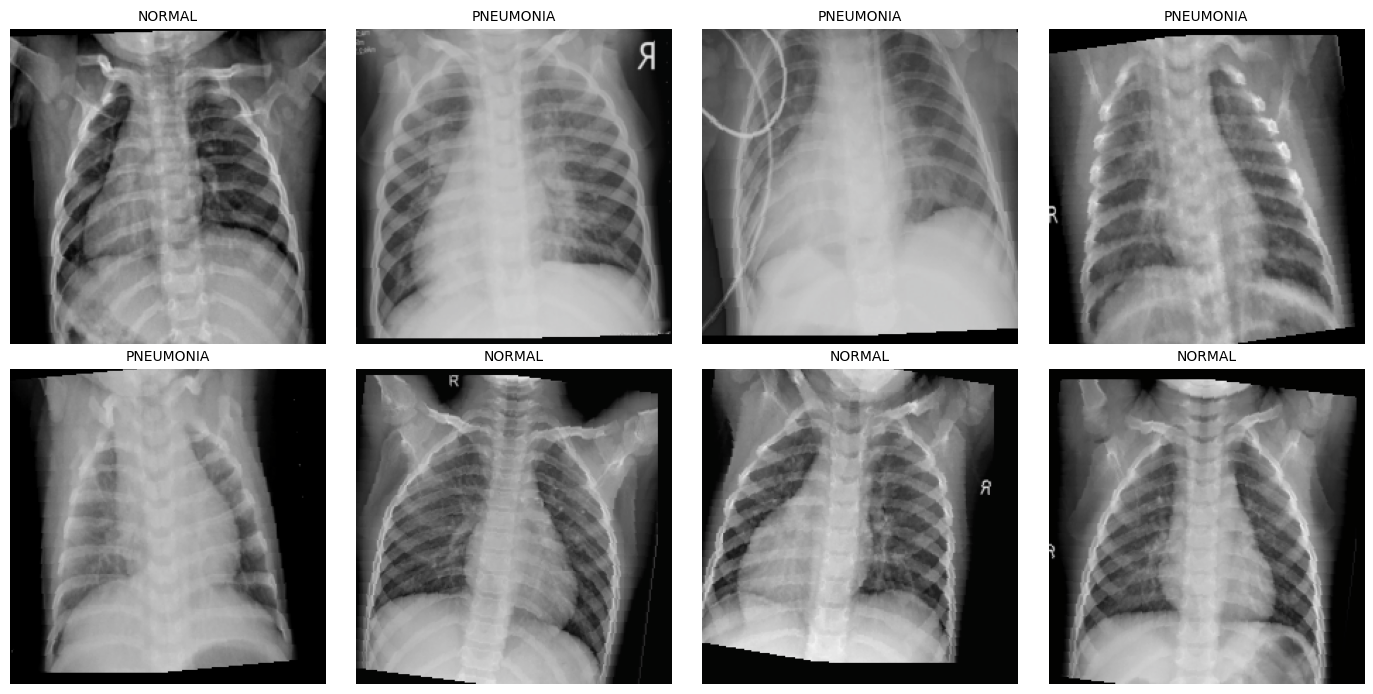

In [ ]:
# visualize one augmented batch
imgs, lbls = next(iter(train_loader))

mean = np.array(IMAGENET_MEAN)
std  = np.array(IMAGENET_STD)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img = imgs[i].permute(1, 2, 0).numpy()
    img = img * std + mean
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title("NORMAL" if lbls[i].item() == 0 else "PNEUMONIA", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_augmented_batch.png", dpi=150)
plt.show()

In [ ]:
#  save splits for reproducibility
splits_data = {
    "data_dir":     str(DATA_DIR),
    "train_files":  [str(p) for p in train_files],
    "train_labels": list(map(int, train_labels)),
    "val_files":    [str(p) for p in val_files],
    "val_labels":   list(map(int, val_labels)),
    "test_files":   [str(p) for p in test_files],
    "test_labels":  list(map(int, test_labels)),
    "class_weights": class_weights.tolist(),
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
}

out = RES_DIR / "splits.json"
with open(out, "w") as f:
    json.dump(splits_data, f, indent=2)

print("Saved:", out)
print("File size (KB):", round(out.stat().st_size / 1024, 1))

Saved: C:\Users\Admin\lungprints\results\splits.json
File size (KB): 679.1


In [ ]:
# sanity checks: reload splits
with open(RES_DIR / "splits.json") as f:
    loaded = json.load(f)

assert len(loaded["train_files"]) == len(train_files)
assert len(loaded["val_files"])   == len(val_files)
assert len(loaded["test_files"])  == len(test_files)
assert loaded["img_size"] == IMG_SIZE

print("Sanity check passed.")
print("Train/Val/Test:", len(loaded["train_files"]),
                      len(loaded["val_files"]),
                      len(loaded["test_files"]))
print("Class weights from file:", loaded["class_weights"])

Sanity check passed.
Train/Val/Test: 4185 1047 624
Class weights from file: [1.9392956495285034, 0.6736961007118225]
